# CIFAR-10 Image Classification with a CNN (Beginner Friendly)

In this notebook we will build a **Convolutional Neural Network (CNN)** to classify small color images into 10 categories using the **CIFAR-10** dataset.

### What is CIFAR-10?
A dataset of 60,000 tiny color images (32x32 pixels), split into 10 classes:
`plane, car, bird, cat, deer, dog, frog, horse, ship, truck`

### What you'll learn
1. Loading and exploring image data
2. Preprocessing images for a neural network
3. Building a CNN layer by layer
4. Training and evaluating the model
5. Visualizing results and making predictions

### Requirements
```
pip install tensorflow matplotlib numpy
```


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tensorflow matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 770.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 142.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 110.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


## Step 1: Import Libraries

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Step 2: Load the CIFAR-10 Dataset

Keras includes CIFAR-10 built in, so we don't need to download it manually.

- `x_train` / `x_test` = the images
- `y_train` / `y_test` = the labels (a number 0-9 telling us what's in the image)


In [5]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.cifar10.load_data()

class_names = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape:", x_train_raw.shape)  # (50000, 32, 32, 3)
print("Training labels shape:", y_train_raw.shape)  # (50000, 1)
print("Test images shape:", x_test_raw.shape)        # (10000, 32, 32, 3)
print("Test labels shape:", y_test_raw.shape)        # (10000, 1)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1323s 8us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


## Step 3: Look at Some Sample Images

It always helps to look at your data before training on it.


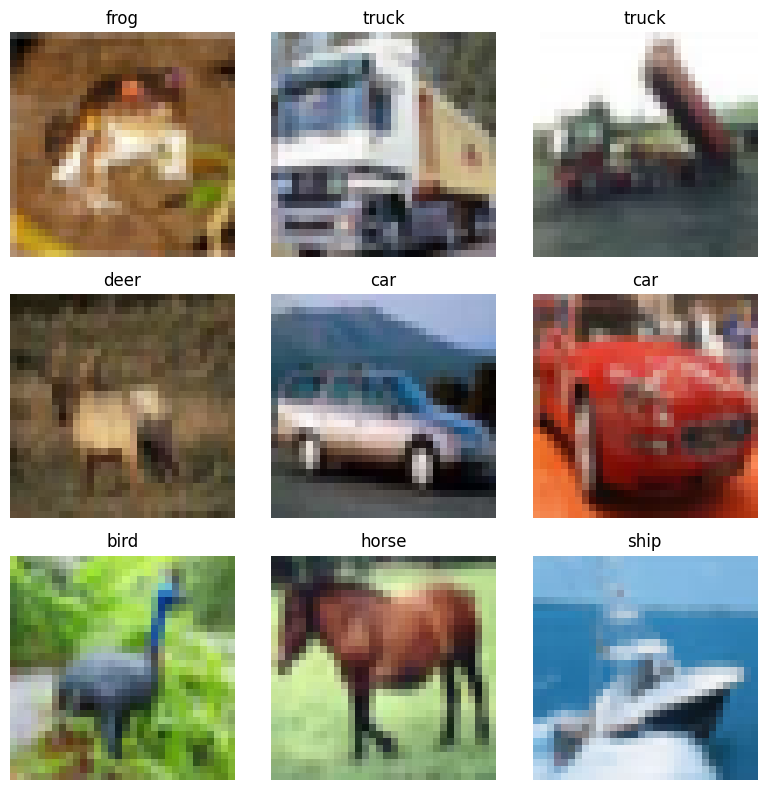

In [6]:
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train_raw[i])
    plt.title(class_names[y_train_raw[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()


## Step 4: Preprocess the Data

**Scaling pixel values:** Pixel values normally range from 0-255. Neural networks train better and faster when input numbers are small, so we scale them down to the range 0-1.

**Flattening labels:** Labels come as `[[3], [8], [1], ...]` (a 2D array). We flatten them into a simple 1D list: `[3, 8, 1, ...]` for convenience.


In [7]:
# Scale pixel values from 0-255 down to 0-1
x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0

# Flatten the labels from [[3], [8], ...] to [3, 8, ...] for  sparse_categorical_crossentropy
#y_train = y_train.flatten()
#y_test = y_test.flatten()

print("New training images shape:", x_train.shape)
print("New training labels shape:", y_train_raw.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())


New training images shape: (50000, 32, 32, 3)
New training labels shape: (50000, 1)
Pixel value range: 0.0 to 1.0


In [8]:
# (x_train_data, x_valid) = x_train_raw[5000:], x_train_raw[:5000]
# (y_train_data, y_valid) = y_train_raw[5000:], y_train_raw[:5000]

# from tensorflow.keras.utils import to_categorical

# # one-hot encode the labels
# num_classes = 10
# y_train_data = to_categorical(y_train_data, num_classes)
# y_valid = to_categorical(y_valid, num_classes)
# y_test = to_categorical(y_test, num_classes)

# break training set into training and validation sets
(x_train_data, x_valid) = x_train[5000:], x_train[:5000]
(y_train_data, y_valid) = y_train_raw[5000:], y_train_raw[:5000]

from tensorflow.keras.utils import to_categorical

num_classes = 10
y_train_data = to_categorical(y_train_data, num_classes)
y_valid = to_categorical(y_valid, num_classes)
y_test = to_categorical(y_test_raw, num_classes)

## Step 5: Build the CNN Model

A CNN learns to recognize visual patterns (edges, shapes, textures) using **convolution** layers, then makes a final decision using regular **dense** layers.

| Layer | Purpose |
|---|---|
| `Conv2D` | Slides small filters over the image to detect features like edges and colors |
| `MaxPooling2D` | Shrinks the image size while keeping the most important information |
| `Flatten` | Converts 2D feature maps into a 1D list of numbers |
| `Dense` | A regular neural network layer that makes decisions |
| `Dropout` | Randomly turns off some neurons during training to prevent overfitting |


In [9]:
model = models.Sequential([

    # --- Convolution Block 1 ---
    # 32 filters, each 3x3 pixels, learn simple patterns like edges
    layers.Conv2D(32, (3, 3), activation="relu", padding='same',input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # --- Convolution Block 2 ---
    # 64 filters, learn more complex patterns
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # --- Convolution Block 3 ---
    layers.Conv2D(64, (3, 3), activation="relu"),

    # Flatten 2D feature maps into a 1D vector
    layers.Flatten(),

    # Dense layer for decision-making
    layers.Dense(64, activation="relu"),

    # Dropout to reduce overfitting
    layers.Dropout(0.5),

    # Output layer: 10 neurons (one per class), softmax gives probabilities
    layers.Dense(10, activation="softmax"),
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,434 (622.79 KB)

 Trainable params: 159,434 (622.79 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Compile the Model

- **optimizer**: how the model updates itself to improve (`adam` is a solid default)
- **loss**: measures how wrong the predictions are. Since our labels are plain integers (not one-hot encoded), we use `sparse_categorical_crossentropy`
- **metrics**: what we track during training — accuracy is easy to interpret


In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)


In [11]:
y_train_data

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [12]:
x_train[1:10]

array([[[[0.6039216 , 0.69411767, 0.73333335],
         [0.49411765, 0.5372549 , 0.53333336],
         [0.4117647 , 0.40784314, 0.37254903],
         ...,
         [0.35686275, 0.37254903, 0.2784314 ],
         [0.34117648, 0.3529412 , 0.2784314 ],
         [0.30980393, 0.31764707, 0.27450982]],

        [[0.54901963, 0.627451  , 0.6627451 ],
         [0.5686275 , 0.6       , 0.6039216 ],
         [0.49019608, 0.49019608, 0.4627451 ],
         ...,
         [0.3764706 , 0.3882353 , 0.30588236],
         [0.3019608 , 0.3137255 , 0.24313726],
         [0.2784314 , 0.28627452, 0.23921569]],

        [[0.54901963, 0.60784316, 0.6431373 ],
         [0.54509807, 0.57254905, 0.58431375],
         [0.4509804 , 0.4509804 , 0.4392157 ],
         ...,
         [0.30980393, 0.32156864, 0.2509804 ],
         [0.26666668, 0.27450982, 0.21568628],
         [0.2627451 , 0.27058825, 0.21568628]],

        ...,

        [[0.6862745 , 0.654902  , 0.6509804 ],
         [0.6117647 , 0.6039216 , 0.627451  ]

## Step 7: Train the Model

- **epochs**: how many times the model passes through the entire training set
- **validation_data**: data the model never trains on, used to check if it's genuinely learning (not just memorizing)

This may take a few minutes depending on your machine (faster with a GPU).


In [13]:
from keras.callbacks import ModelCheckpoint

# train the model
checkpointer = ModelCheckpoint(filepath='model.weights.best.keras', save_best_only=True)


EPOCHS = 10

history = model.fit(
    x_train_data, y_train_data,
    epochs=EPOCHS,
    validation_data=(x_valid, y_valid),
    callbacks=[checkpointer],
    verbose=1,
    shuffle=True
)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 53ms/step - accuracy: 0.3486 - loss: 1.7582 - val_accuracy: 0.5172 - val_loss: 1.3450
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.4838 - loss: 1.4304 - val_accuracy: 0.5874 - val_loss: 1.1534
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.5428 - loss: 1.2795 - val_accuracy: 0.6228 - val_loss: 1.0592
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.5829 - loss: 1.1809 - val_accuracy: 0.6248 - val_loss: 1.0544
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.6103 - loss: 1.1047 - val_accuracy: 0.6566 - val_loss: 0.9616
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 73s 52ms/step - accuracy: 0.6387 - loss: 1.0365 - val_accuracy: 0.6822 - val_loss: 0.9154
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.6560 - loss: 0.9867 - val_accuracy: 0.6838 - val_loss: 0.9232
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.6712 -

## Step 8: Evaluate on the Test Set

In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc * 100:.2f}%")


313/313 - 4s - 14ms/step - accuracy: 0.7077 - loss: 0.8603

Test accuracy: 70.77%


## Step 9: Plot Training Progress

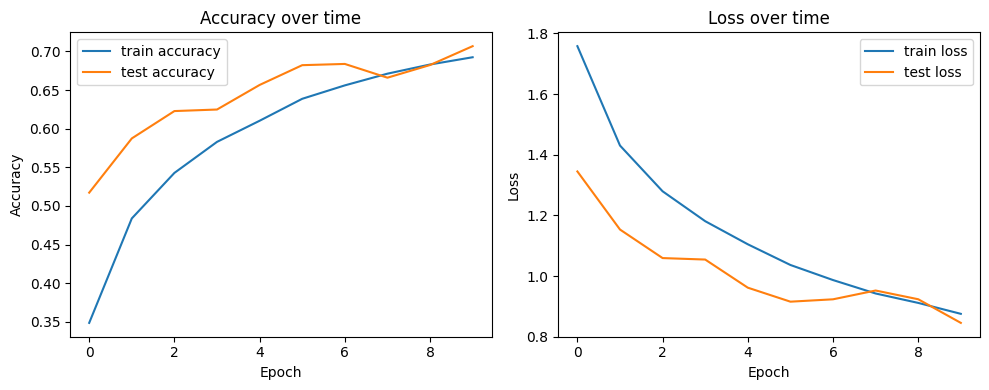

In [15]:

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over time")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over time")

plt.tight_layout()
plt.show()


## Step 10: Make a Prediction

Let's test the model on a single image from the test set and see what it predicts.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


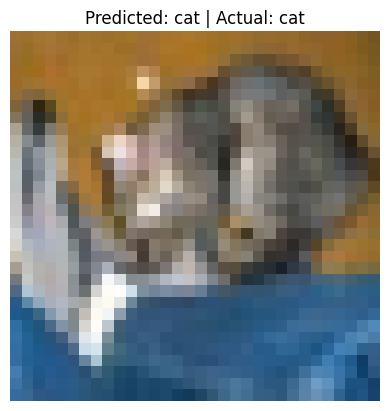

Prediction probabilities:
  plane   :  0.30%
  car     :  0.29%
  bird    :  3.14%
  cat     : 48.40%
  deer    :  1.17%
  dog     : 39.62%
  frog    :  2.37%
  horse   :  3.35%
  ship    :  0.36%
  truck   :  0.99%


In [16]:
sample_index = 0
sample = x_test[sample_index]

prediction = model.predict(np.expand_dims(sample, axis=0))
predicted_class = class_names[np.argmax(prediction)]
#actual_class = class_names[y_test[sample_index]]
actual_class = class_names[np.argmax(y_test[sample_index])]

plt.imshow(sample)
plt.axis("off")
plt.title(f"Predicted: {predicted_class} | Actual: {actual_class}")
plt.show()

print("Prediction probabilities:")
for name, prob in zip(class_names, prediction[0]):
    print(f"  {name:8s}: {prob*100:5.2f}%")


## Step 11: Save the Trained Model

Save it so you can reload it later without retraining.


In [17]:
model.save("cifar10_cnn_trained.keras")
print("Model saved to cifar10_cnn_trained.keras")


Model saved to cifar10_cnn_trained.keras
